In [2]:
dic = {
	" ": 74059,
	"x": 15948,
	"d": 14681,
	"e": 13974,
	"5": 13610,
	"N": 13466,
	"4": 13238,
	"6": 12418,
	"R": 11999,
	"c": 11965,
	"f": 11735,
	"B": 11237,
	"3": 10695,
	"Q": 8913,
	"b": 8060,
	"g": 7991,
	"7": 7432,
	"K": 7004,
	"2": 5861,
	"a": 5644,
	"h": 5567,
	"8": 5228,
	"+": 4546,
	"1": 4145,
	"O": 3419,
	"-": 1817,
	"#": 142,
	"=": 86,
}

In [3]:
from huffman_compression import build_huffman_tree, generate_huffman_codes, decode_huffman

chars = list(dic.keys())
freq = list(dic.values())
root = build_huffman_tree(chars, freq)

huffman_codes = generate_huffman_codes(root)

for char, code in huffman_codes.items():
    print(f"Character: {char}, Code: {code}")

Character: 5, Code: 0000
Character: e, Code: 0001
Character: d, Code: 0010
Character: 7, Code: 00110
Character: g, Code: 00111
Character:  , Code: 01
Character: x, Code: 1000
Character: b, Code: 10010
Character: 1, Code: 100110
Character: +, Code: 100111
Character: Q, Code: 10100
Character: 8, Code: 101010
Character: =, Code: 101011000
Character: #, Code: 101011001
Character: -, Code: 10101101
Character: O, Code: 1010111
Character: 3, Code: 10110
Character: h, Code: 101110
Character: a, Code: 101111
Character: B, Code: 11000
Character: f, Code: 11001
Character: c, Code: 11010
Character: R, Code: 11011
Character: 6, Code: 11100
Character: 2, Code: 111010
Character: K, Code: 111011
Character: 4, Code: 11110
Character: N, Code: 11111


In [4]:
with open('every_move.txt', 'r') as f:
    every_move = [x[:-1] for x in f.readlines()]

In [ ]:
dimension_huffman = 0
dimension_no_huffman = 0

SPACE_LEN = len(huffman_codes[" "])

for move in every_move:
    dimension_no_huffman += (len(move) + 1) * 5 # space ' ' count
    for x in move:
        dimension_huffman += len(huffman_codes[x]) if x in huffman_codes else 0
    dimension_huffman += SPACE_LEN

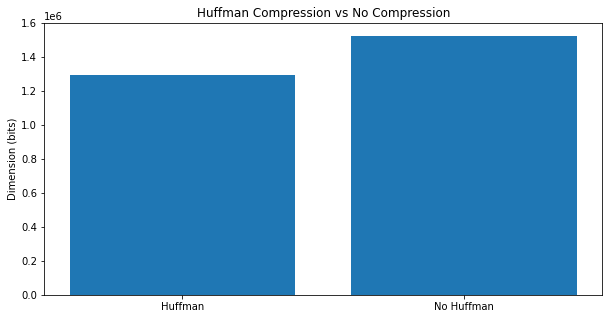

With Huffman Dimension:	1.295206e+06
No Huffman Dimension:	1.524400e+06
Saved 15.035030% space


In [8]:
# plot comparison of dimensions
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(['Huffman', 'No Huffman'], [dimension_huffman, dimension_no_huffman])
plt.ylabel('Dimension (bits)')
plt.title('Huffman Compression vs No Compression')
plt.show()
print(f'With Huffman Dimension:\t{dimension_huffman:e}')
print(f'No Huffman Dimension:\t{dimension_no_huffman:e}')

print(f'Saved {(100 * (dimension_no_huffman - dimension_huffman) / dimension_no_huffman):f}% space')